## 1D GP Surrogate Predictions

This notebook demonstrates `plot_gp_predictions_1D`, which visualizes the GP surrogate model by sweeping each input parameter individually while holding all other parameters fixed. This is useful for understanding how sensitive the surrogate is to each dimension and for sanity-checking the GP fit in higher-dimensional problems where 2D contour plots are unavailable.

For each dimension the plot shows:
- **GP predictive mean** as a function of that parameter
- **Uncertainty band** (±2σ) around the mean
- **Training data** projected onto that parameter axis
- **Vertical dashed line** marking the reference value

The reference point is typically the surrogate maximum, obtained with `find_max_surrogate`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from scipy.stats import multivariate_normal
from sklearn import preprocessing

import alabi
import alabi.visualization as vis
from alabi.core import SurrogateModel

from matplotlib import rcParams
# rcParams['font.family'] = 'serif'
# rcParams['text.usetex'] = True

np.random.seed(42)

### Define a 4D Gaussian likelihood

We use a 4-dimensional correlated Gaussian as the test likelihood. This is a natural target for `plot_gp_predictions_1D` — with 4 parameters a 2D contour plot can only show pairwise projections, but the 1D slices give a direct view of how each dimension contributes to the surrogate surface.

In [2]:
ndim = 4

# True peak at the origin with a moderately correlated covariance
mean = np.zeros(ndim)
cov  = np.array([
    [1.00,  0.60,  0.30, -0.20],
    [0.60,  1.00,  0.10,  0.40],
    [0.30,  0.10,  1.00,  0.50],
    [-0.20, 0.40,  0.50,  1.00],
])

lnlike = partial(multivariate_normal.logpdf, mean=mean, cov=cov)

bounds = [(-4., 4.)] * ndim
param_names = [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\theta_4$"]

### Train the surrogate model

First we'll compute some initial training samples

In [3]:
sm = SurrogateModel(
    lnlike_fn=lnlike,
    bounds=bounds,
    param_names=param_names,
    savedir="results/gp_predictions_1d",
    verbose=False,
)

sm.init_samples(ntrain=40, sampler="lhs")

Here we will scale the input data using a minmax scaler so that $\theta_i \in [0,1]$ using the option:

```python
theta_scaler=preprocessing.MinMaxScaler()
```

Now, since $\theta_i$ span [0,1], we might expect the length scales of the variation to be around ~0.1. We will set the length scale hyperparameter range to be between [0.1, 1], or in log scale:
```python
gp_scale_rng=[-1,1]
```

We will also set the amplitude range of the fit to be near the same order of magnitude as the variance in the training data

In [4]:
np.var(sm.y_train), np.log10(np.var(sm.y_train))

(np.float64(18410.313443996398), np.float64(4.265061182628903))

The log variance is around ~4, so we will set the GP amplitude bounds to be around this value. The length scale bounds are set to be fairly wide, but we will scale the inputs to be between 0 and 1, which should help with optimization.
```python
gp_amp_rng=[3.,5.]
```

In [5]:
sm.init_gp(
    kernel="ExpSquaredKernel",
    fit_amp=True,
    fit_mean=True,
    fit_white_noise=False,
    white_noise=-12,
    gp_opt_method="l-bfgs-b",
    theta_scaler=preprocessing.MinMaxScaler(),
    gp_scale_rng=[-1.,1.], 
    gp_amp_rng=[3.,5.],
)
sm.active_train(
    niter=60,
    algorithm="bape",
    gp_opt_freq=20,
    obj_opt_method="nelder-mead",
    nopt=3,
)

Initialized GP with squared exponential kernel.
Successfully initialized GP on attempt 1
Evaluating 100 hyperparameter candidates using 5-fold CV...


 30%|███       | 18/60 [00:01<00:04, 10.45it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


 65%|██████▌   | 39/60 [00:04<00:02,  9.35it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


 98%|█████████▊| 59/60 [00:07<00:00,  9.11it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


100%|██████████| 60/60 [00:08<00:00,  7.47it/s]

Caching model to results/gp_predictions_1d/surrogate_model...


### Plot 1D GP predictions

Call `plot_gp_predictions_1D` directly, passing the surrogate maximum as the reference point. Each panel sweeps one parameter across its full range while the remaining parameters are held fixed at `theta_max`. The true log-likelihood (black dashed line) is overplotted for comparison.


Saving to  results/gp_predictions_1d/gp_predictions_1D.png


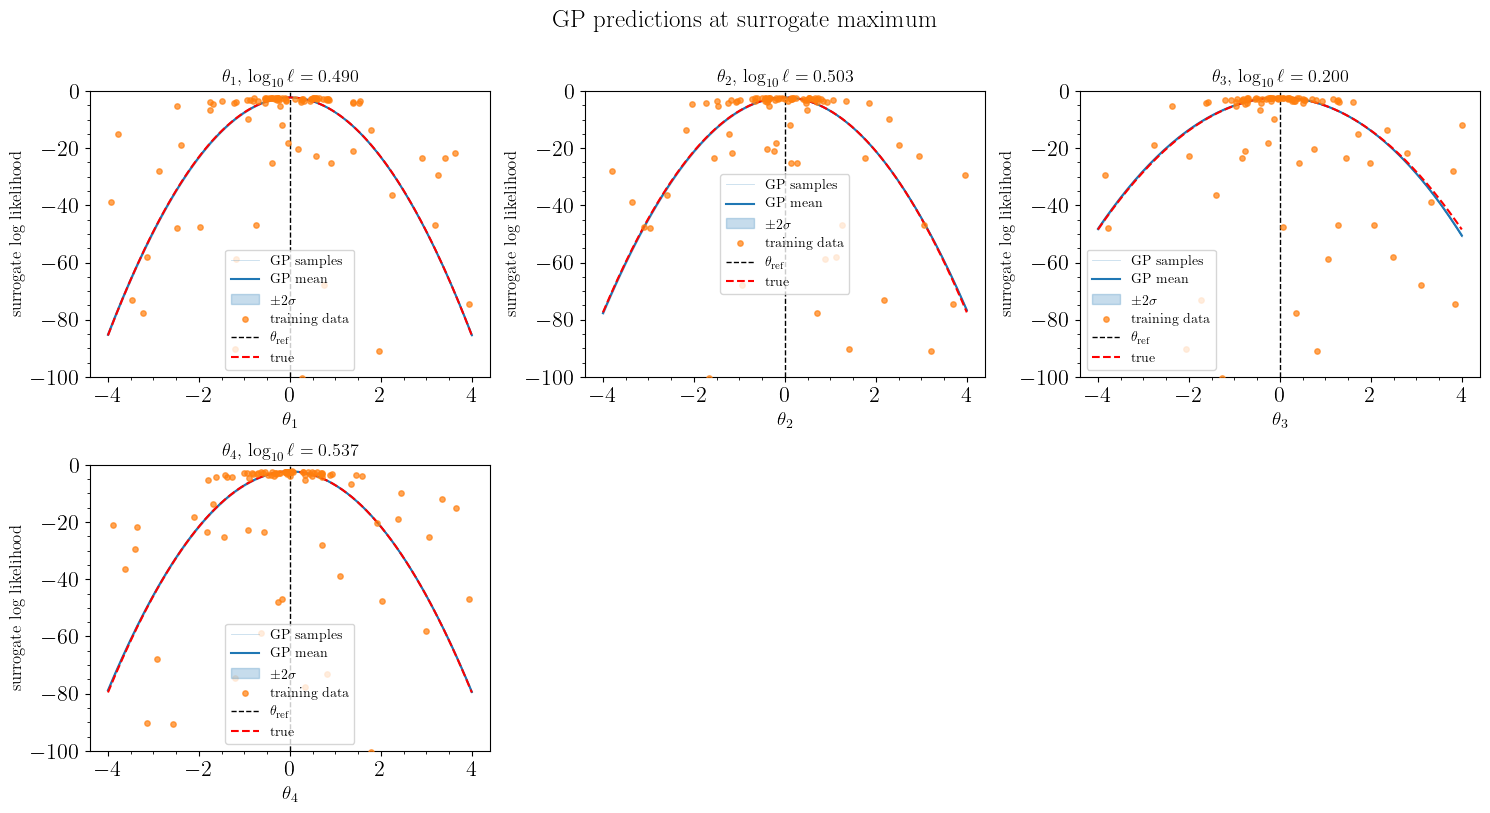

In [6]:
from IPython.display import display

theta_plot = np.zeros(sm.ndim)

fig = vis.plot_gp_predictions_1D(
    sm,
    theta=theta_plot,  
    ngrid=150,
    nsigma=2,
    title="GP predictions at surrogate maximum",
    savedir="results/gp_predictions_1d",
    show=False,
    ylim=[-100, 0],
    plot_samples=10,
)

# Overplot the true log-likelihood on each panel
ngrid = 150
for dim in range(sm.ndim):
    ax = fig.axes[dim]
    xarr = np.linspace(sm.bounds[dim][0], sm.bounds[dim][1], ngrid)
    sweep = np.tile(theta_plot, (ngrid, 1))
    sweep[:, dim] = xarr
    true_y = np.array([sm.true_log_likelihood(t) for t in sweep])
    ax.plot(xarr, true_y, color="r", lw=1.5, ls="--", label="true")
    ax.legend(fontsize=10, loc="best")

display(fig)
plt.close(fig)


### Use a custom reference point

Any point in parameter space can serve as the reference. `find_max_surrogate` runs multi-start optimization to locate the parameter values where the GP predictive mean is highest. This is a natural reference point for the 1D slices — it shows a cross-section through the region the surrogate model considers most likely.

In [8]:
theta_max, y_max = sm.find_max_surrogate(nopt=20)

print("Surrogate maximum:")
for name, val in zip(param_names, theta_max):
    print(f"  {name} = {val:.4f}")
print(f"\nSurrogate log-likelihood at maximum: {y_max:.4f}")
print(f"True log-likelihood at maximum:      {lnlike(theta_max):.4f}")

Surrogate maximum:
  $\theta_1$ = 0.0306
  $\theta_2$ = 0.0038
  $\theta_3$ = -0.1694
  $\theta_4$ = -0.1503

Surrogate log-likelihood at maximum: -2.2849
True log-likelihood at maximum:      -2.2847


Best training point:
  $\theta_1$ = 0.0306
  $\theta_2$ = 0.0038
  $\theta_3$ = -0.1694
  $\theta_4$ = -0.1503

Observed log-likelihood: -2.3056
Saving to  results/gp_predictions_1d/gp_predictions_1D_surrogate_max.png


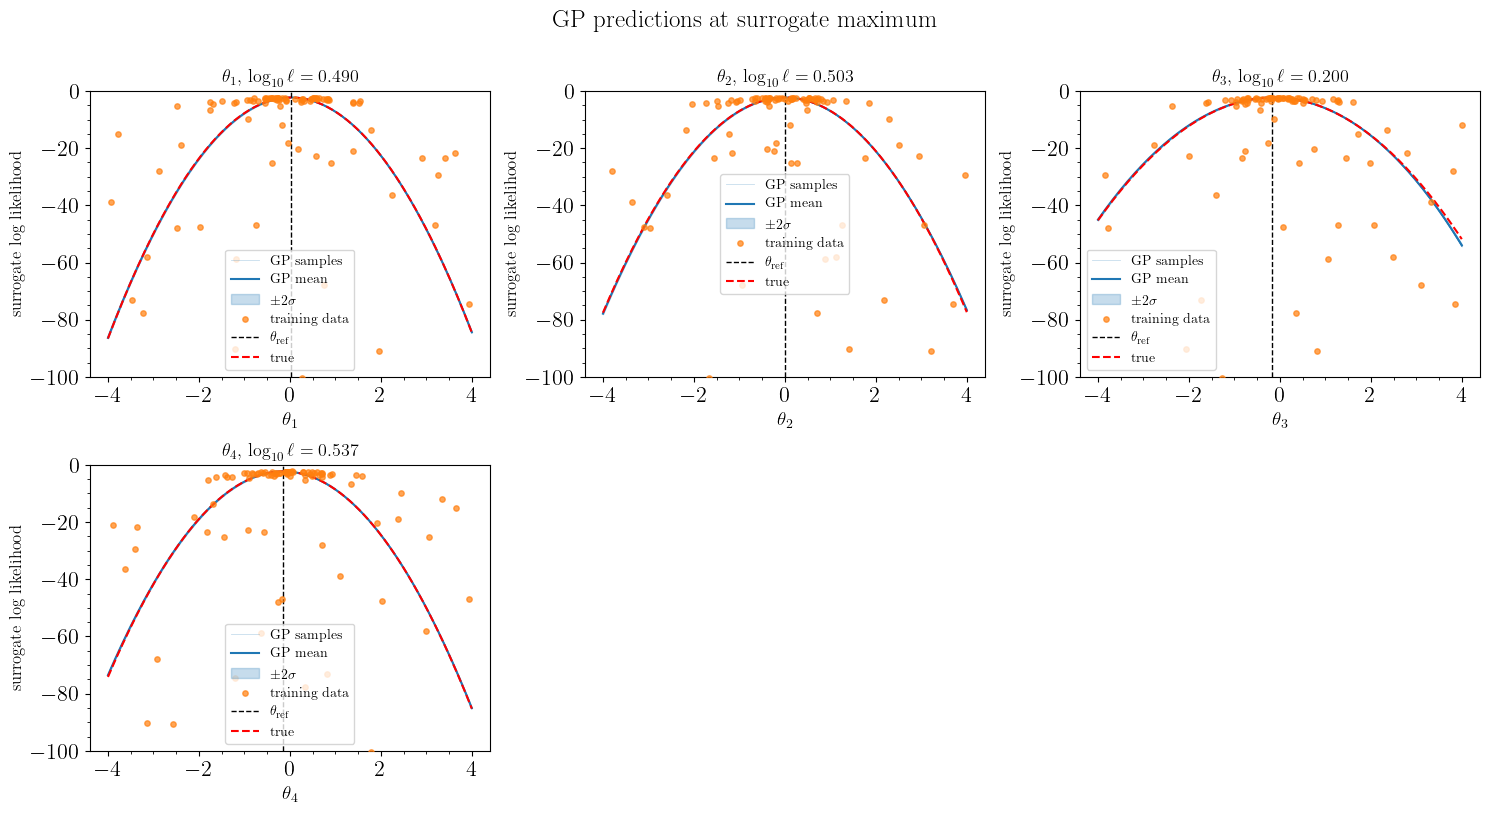

In [9]:
print("Best training point:")
for name, val in zip(param_names, theta_max):
    print(f"  {name} = {val:.4f}")
print(f"\nObserved log-likelihood: {np.max(sm.y()):.4f}")

fig = vis.plot_gp_predictions_1D(
    sm,
    theta=theta_max,
    ngrid=150,
    nsigma=2,
    title="GP predictions at surrogate maximum",
    savedir="results/gp_predictions_1d",
    savename="gp_predictions_1D_surrogate_max.png",
    show=False,
    ylim=[-100, 0],
    plot_samples=10,
)

# Overplot the true log-likelihood on each panel
ngrid = 150
for dim in range(sm.ndim):
    ax = fig.axes[dim]
    xarr = np.linspace(sm.bounds[dim][0], sm.bounds[dim][1], ngrid)
    sweep = np.tile(theta_max, (ngrid, 1))
    sweep[:, dim] = xarr
    true_y = np.array([sm.true_log_likelihood(t) for t in sweep])
    ax.plot(xarr, true_y, color="r", lw=1.5, ls="--", label="true")
    ax.legend(fontsize=10, loc="best")

display(fig)
plt.close(fig)

### Call via `sm.plot`

`plot_gp_predictions_1D` is also integrated into `SurrogateModel.plot`. When called this way the reference point is automatically set to the surrogate maximum via `find_max_surrogate`. This function can be called using

```python
sm.plot(plots=["gp_predictions_1D"], show=True)
```

### When is this diagnostic useful?

Let's try another example where we don't scale the training data and bound the length scales to very small values in the range [0.0001, 0.01], or in log scale:
```python
gp_scale_rng=[-4,-2]
```

In [10]:
sm = SurrogateModel(
    lnlike_fn=lnlike,
    bounds=bounds,
    param_names=param_names,
    savedir="results/gp_predictions_1d",
    verbose=False,
)

sm.init_samples(ntrain=40, sampler="lhs")
sm.init_gp(
    kernel="ExpSquaredKernel",
    fit_amp=True,
    fit_mean=True,
    fit_white_noise=False,
    white_noise=-12,
    gp_opt_method="l-bfgs-b",
    theta_scaler=preprocessing.MinMaxScaler(),
    gp_scale_rng=[-4.,-2.],
    gp_amp_rng=[3.,5.],
)
sm.active_train(
    niter=60,
    algorithm="bape",
    gp_opt_freq=20,
    obj_opt_method="nelder-mead",
    nopt=3,
)

Initialized GP with squared exponential kernel.
Successfully initialized GP on attempt 1
Evaluating 100 hyperparameter candidates using 5-fold CV...


 30%|███       | 18/60 [00:00<00:01, 23.35it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


 65%|██████▌   | 39/60 [00:04<00:02,  7.10it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


 97%|█████████▋| 58/60 [00:07<00:00,  8.57it/s]

Evaluating 100 hyperparameter candidates using 5-fold CV...


100%|██████████| 60/60 [00:07<00:00,  7.64it/s]

Caching model to results/gp_predictions_1d/surrogate_model...


Saving to  results/gp_predictions_1d/gp_predictions_1D.png


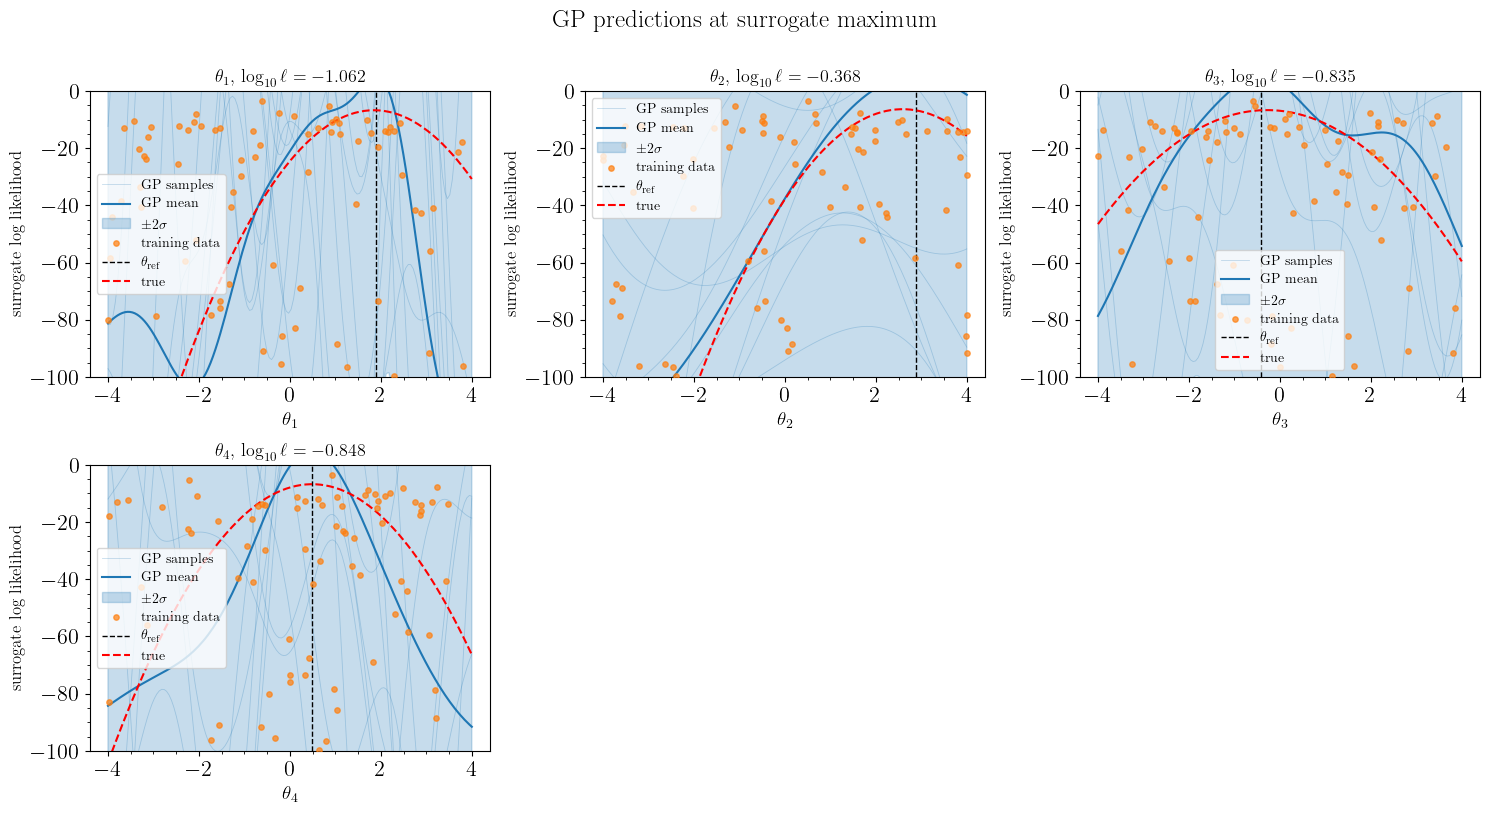

In [11]:
theta_max, y_max = sm.find_max_surrogate(nopt=20)

fig = vis.plot_gp_predictions_1D(
    sm,
    theta=theta_max,
    ngrid=150,
    nsigma=2,
    title="GP predictions at surrogate maximum",
    savedir="results/gp_predictions_1d",
    show=False,
    ylim=[-100, 0],
    plot_samples=10,
)

# Overplot the true log-likelihood on each panel
ngrid = 150
for dim in range(sm.ndim):
    ax = fig.axes[dim]
    xarr = np.linspace(sm.bounds[dim][0], sm.bounds[dim][1], ngrid)
    sweep = np.tile(theta_max, (ngrid, 1))
    sweep[:, dim] = xarr
    true_y = np.array([sm.true_log_likelihood(t) for t in sweep])
    ax.plot(xarr, true_y, color="r", lw=1.5, ls="--", label="true")
    ax.legend(fontsize=10, loc="best")

display(fig)
plt.close(fig)

From the 1D diagnostic plot, we see that the prediction uncertainty is much larger and the mean prediction deviates quite a bit from the true model. Looking at some of the individual functions sampled from the GP, we can see that this high prediction variance is due to many of the functions being very "wiggly" or over-fitting to the data, which is an indication that the length scales of the fit are too small and the prior range `gp_scale_rng` needs to be adjusted.  